# Total Time Spent on Question
Checks the time the candidate spend on a question. 

The test will be marked as "slow" if the time it took was more than the mean plus the standard deviation and marked as "too fast" if the time it took was more than the mean minus the standard deviation. 

The mean and the standard deviation are calculated over all questions with the same ItemId. 

In [1]:
import pandas as pd
import pyodbc  
import matplotlib.pyplot as plt

## Import Data from csv

In [2]:
sjt_question = pd.read_csv("../../../decoded_data/SJT/FactQuestionSJT.csv")

## Data Inspection

In [3]:
sjt_question.head()

,QuestionKey,InstanceID,ItemID,AnswerSequence1,AnswerSequence2,AnswerSequence3,TimeSpent,Test,TestKey
0,1,1,1,5,4,2,181,SJT,160068
1,2,1,2,4,3,2,172,SJT,160068
2,3,1,3,4,2,3,136,SJT,160068
3,4,1,4,3,2,4,266,SJT,160068
4,5,1,5,2,5,1,198,SJT,160068


In [4]:
sjt_question.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89622 entries, 0 to 89621
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   QuestionKey      89622 non-null  int64 
 1   InstanceID       89622 non-null  int64 
 2   ItemID           89622 non-null  int64 
 3   AnswerSequence1  89622 non-null  int64 
 4   AnswerSequence2  89622 non-null  int64 
 5   AnswerSequence3  89622 non-null  int64 
 6   TimeSpent        89622 non-null  int64 
 7   Test             89622 non-null  object
 8   TestKey          89622 non-null  int64 
dtypes: int64(8), object(1)
memory usage: 6.2+ MB


## Detection Function

The standerd deviation can return Nan if the variation is too small. We will in that case work with zero. 

In [5]:
df_items = sjt_question[["ItemID", "TimeSpent"]]

df_items = df_items.groupby('ItemID')['TimeSpent'].agg(['mean', 'std']).reset_index().rename(columns={"mean":"MeanTimeSpent", "std":"StdTimeSpent"})
df_items.fillna(0, inplace=True)
df_items.set_index("ItemID", inplace=True)
df_items.head()

,MeanTimeSpent,StdTimeSpent
ItemID,,
0,0.000000,0.000000
1,88.696683,387.564613
2,67.969327,246.230743
3,85.758731,433.972039
4,87.679273,547.637861


In [6]:
df_items["MaxTime"] = df_items["MeanTimeSpent"] + df_items["StdTimeSpent"]
df_items["MinTime"] = df_items["MeanTimeSpent"] - df_items["StdTimeSpent"]
df_items.head()

,MeanTimeSpent,StdTimeSpent,MaxTime,MinTime
ItemID,,,,
0,0.000000,0.000000,0.000000,0.000000
1,88.696683,387.564613,476.261296,-298.867930
2,67.969327,246.230743,314.200070,-178.261416
3,85.758731,433.972039,519.730771,-348.213308
4,87.679273,547.637861,635.317134,-459.958588


In [7]:
df = sjt_question[["QuestionKey", "ItemID", "TimeSpent"]]
df.head()

,QuestionKey,ItemID,TimeSpent
0,1,1,181
1,2,2,172
2,3,3,136
3,4,4,266
4,5,5,198


In [8]:
def detect_too_slow(ItemId, TimeSpent):
    if TimeSpent > df_items.MaxTime[ItemId]:
        return True
    return False

def detect_too_fast(ItemId, TimeSpent):
    if TimeSpent < df_items.MinTime[ItemId]:
        return True
    return False

## Data Labelling

In [9]:
df["TooSlow"] = df.apply(lambda row: detect_too_slow(row['ItemID'], row['TimeSpent']), axis=1)
df["TooFast"] = df.apply(lambda row: detect_too_fast(row['ItemID'], row['TimeSpent']), axis=1)

df.head()

C:\Users\monad\AppData\Local\Temp\ipykernel_26248\2022903645.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["TooSlow"] = df.apply(lambda row: detect_too_slow(row['ItemID'], row['TimeSpent']), axis=1)
C:\Users\monad\AppData\Local\Temp\ipykernel_26248\2022903645.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["TooFast"] = df.apply(lambda row: detect_too_fast(row['ItemID'], row['TimeSpent']), axis=1)


,QuestionKey,ItemID,TimeSpent,TooSlow,TooFast
0,1,1,181,False,False
1,2,2,172,False,False
2,3,3,136,False,False
3,4,4,266,False,False
4,5,5,198,False,False


## Exporting Data with Anomaly Check

In [10]:
df.set_index("QuestionKey", inplace=True)
df.to_csv("../csv/time_spent_question_checked.csv")
df

,ItemID,TimeSpent,TooSlow,TooFast
QuestionKey,,,,
1,1,181,False,False
2,2,172,False,False
3,3,136,False,False
4,4,266,False,False
5,5,198,False,False
...,...,...,...,...
89618,0,0,False,False
89619,0,0,False,False
89620,0,0,False,False


## Visualisation

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

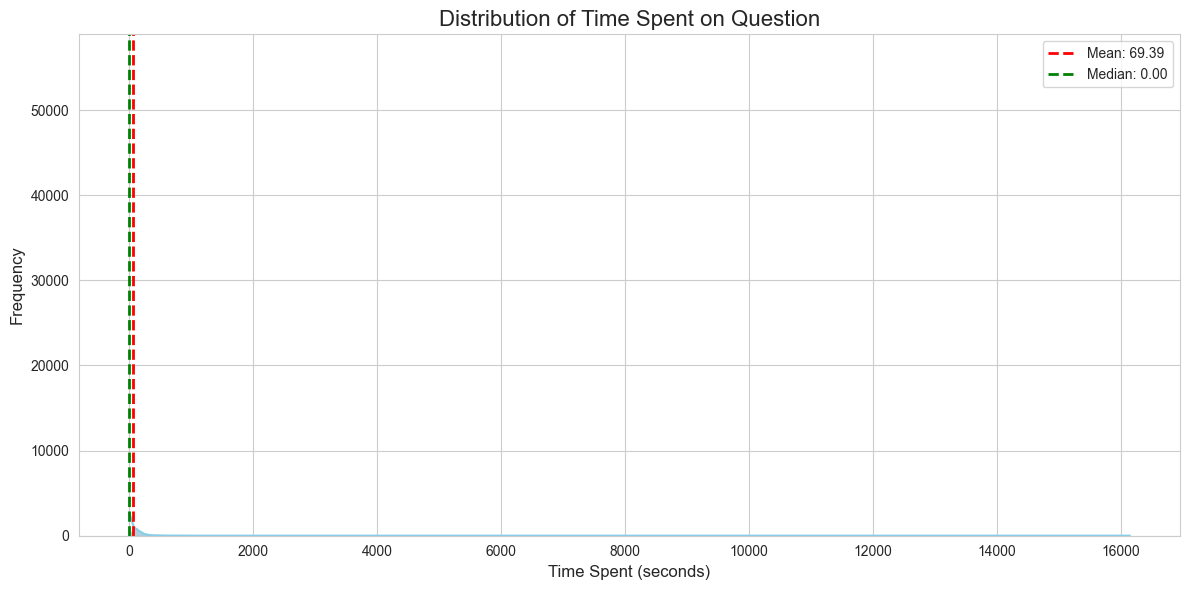

In [12]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# kernel density estimation
sns.histplot(data=df, x='TimeSpent', kde=True, color='skyblue', edgecolor='black')

# name 
plt.title('Distribution of Time Spent on Question', fontsize=16)
plt.xlabel('Time Spent (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add summary statistics
mean_time = df['TimeSpent'].mean()
median_time = df['TimeSpent'].median()

plt.axvline(mean_time, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_time:.2f}')
plt.axvline(median_time, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_time:.2f}')

plt.legend()

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

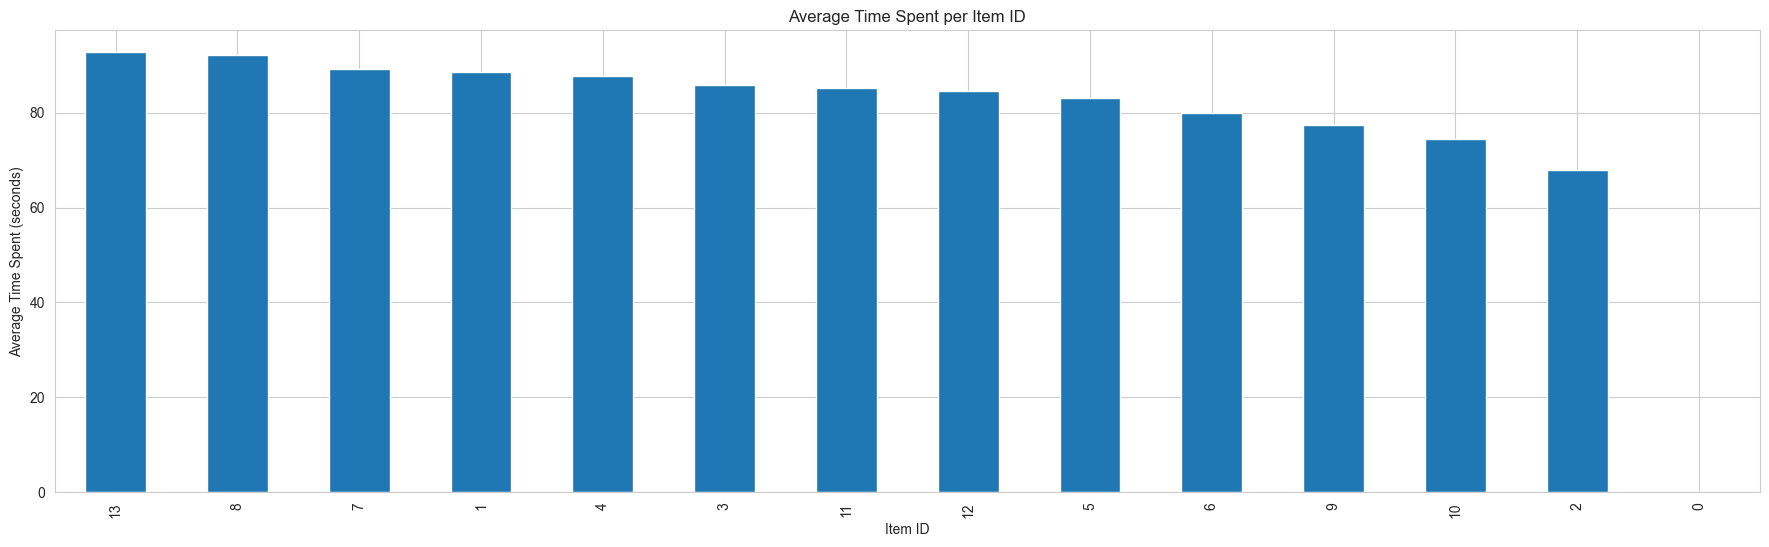

In [13]:
avg_time_per_item = df.groupby('ItemID')['TimeSpent'].mean().sort_values(ascending=False)
plt.figure(figsize=(22, 6))
avg_time_per_item.plot(kind='bar')
plt.title('Average Time Spent per Item ID')
plt.xlabel('Item ID')
plt.ylabel('Average Time Spent (seconds)')
plt.xticks(rotation=90)
plt.show()

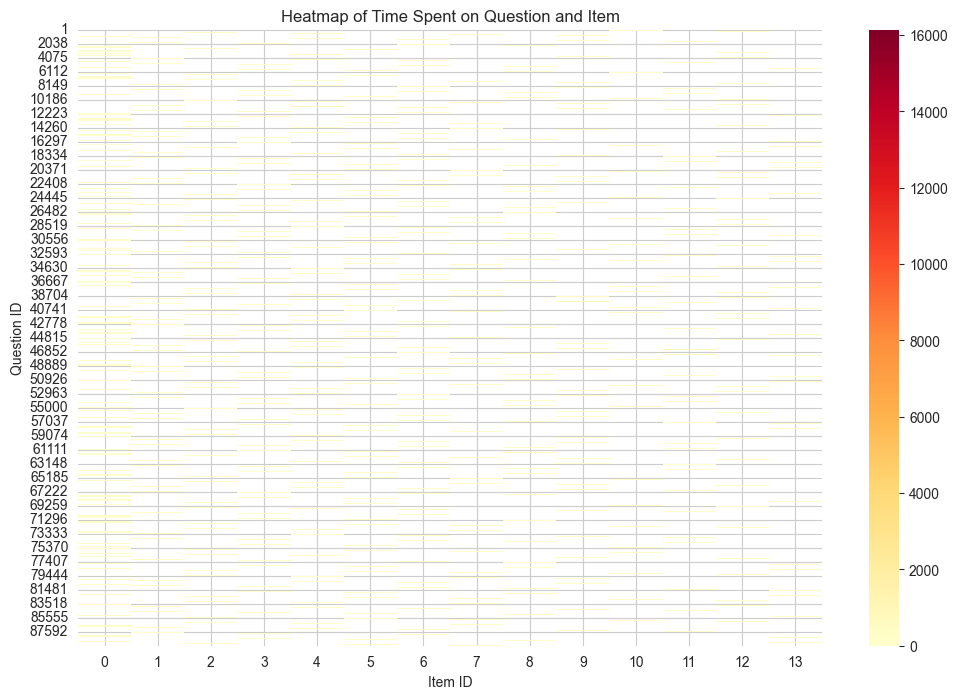

In [14]:
pivot_table = df.pivot_table(values='TimeSpent', index='QuestionKey', columns='ItemID', aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap='YlOrRd')
plt.title('Heatmap of Time Spent on Question and Item')
plt.xlabel('Item ID')
plt.ylabel('Question ID')
plt.show()

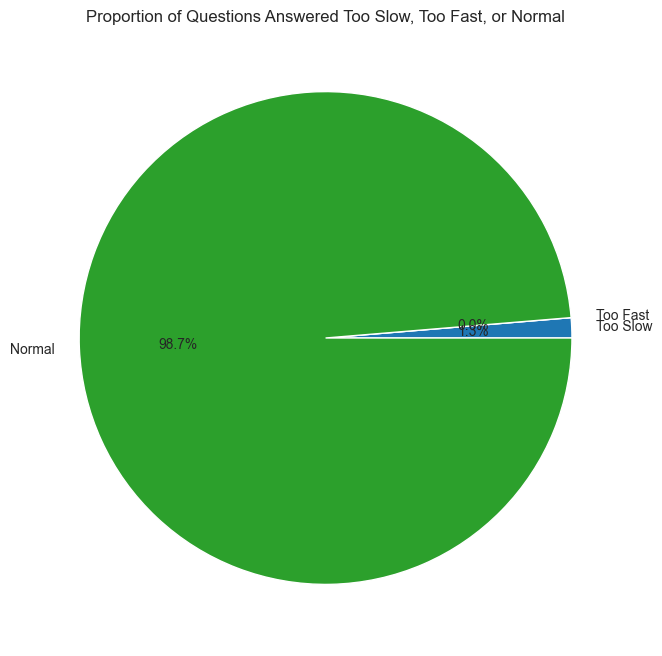

In [15]:
too_slow_count = df['TooSlow'].sum()
too_fast_count = df['TooFast'].sum()
normal_count = len(df) - too_slow_count - too_fast_count

plt.figure(figsize=(8, 8))
plt.pie([too_slow_count, too_fast_count, normal_count], 
        labels=['Too Slow', 'Too Fast', 'Normal'], 
        autopct='%1.1f%%')
plt.title('Proportion of Questions Answered Too Slow, Too Fast, or Normal')
plt.show()